In [1]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

df_fact_ticket = pd.read_csv(PROCESSED_DIR / "fact_ticket.csv")

df_fact_ticket["dob"] = pd.to_datetime(df_fact_ticket["dob"], errors="coerce")
df_fact_ticket["time"] = pd.to_datetime(df_fact_ticket["time"], errors="coerce")

In [2]:
from operator import attrgetter
import matplotlib.pyplot as plt
import seaborn as sns

## Overall retention behavior

In [13]:
df_retention_analysis = df_fact_ticket[
    ["customer_id", "time", "status_id", "campaign_type"]
].copy()

In [14]:
df_retention_analysis = df_retention_analysis[
    (df_retention_analysis["time"] < "2020-01-01") &
    (df_retention_analysis["status_id"] == 1)
]

In [15]:
df_retention_analysis["first_month"] = (
    df_retention_analysis
    .groupby("customer_id")["time"]
    .transform("min")
    .dt.to_period("M")
)

df_retention_analysis["current_month"] = (
    df_retention_analysis["time"]
    .dt.to_period("M")
)

df_retention_analysis["subsequent_month"] = (
    df_retention_analysis["current_month"]
    - df_retention_analysis["first_month"]
).apply(attrgetter("n"))

In [16]:
df_retention_analysis.head(15)

,customer_id,time,status_id,campaign_type,first_month,current_month,subsequent_month
11326,100009,2019-11-09 16:19:41.008,1,direct discount,2019-04,2019-11,7
11327,101892,2019-11-16 16:35:02.953,1,direct discount,2019-08,2019-11,3
11328,105574,2019-11-09 18:10:13.461,1,direct discount,2019-11,2019-11,0
11331,111681,2019-11-16 22:02:42.851,1,direct discount,2019-11,2019-11,0
11332,116896,2019-11-13 17:32:32.892,1,no_campaign,2019-11,2019-11,0
11334,122042,2019-11-17 05:01:48.136,1,direct discount,2019-10,2019-11,1
11335,124200,2019-11-09 10:42:42.694,1,direct discount,2019-11,2019-11,0
11336,131444,2019-11-10 11:12:31.461,1,no_campaign,2019-11,2019-11,0
11337,131562,2019-11-10 17:25:02.482,1,direct discount,2019-11,2019-11,0
11338,134348,2019-11-09 02:10:30.490,1,no_campaign,2019-11,2019-11,0


In [17]:
df_cohort = (
    df_retention_analysis
    .groupby(
        ["first_month", "current_month", "subsequent_month"]
    )
    .agg(
        n_customers=("customer_id", "nunique")
    )
    .reset_index()
)

In [18]:
df_cohort.head(5)

,first_month,current_month,subsequent_month,n_customers
0,2019-01,2019-01,0,1348
1,2019-01,2019-02,1,50
2,2019-01,2019-03,2,35
3,2019-01,2019-04,3,26
4,2019-01,2019-05,4,25


In [19]:
df_cohort_pivot = (
    df_cohort
    .pivot_table(
        index="first_month",
        columns="subsequent_month",
        values="n_customers"
    )
)

In [20]:
df_cohort_pivot

subsequent_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2019-01,1348.0,50.0,35.0,26.0,25.0,33.0,36.0,29.0,18.0,35.0,21.0,20.0
2019-02,1293.0,58.0,88.0,64.0,78.0,50.0,58.0,30.0,46.0,29.0,35.0,NaN
2019-03,745.0,51.0,48.0,49.0,33.0,33.0,30.0,34.0,23.0,14.0,NaN,NaN
2019-04,2922.0,101.0,103.0,87.0,92.0,66.0,96.0,63.0,42.0,NaN,NaN,NaN
2019-05,3226.0,145.0,118.0,129.0,90.0,93.0,90.0,62.0,NaN,NaN,NaN,NaN
2019-06,3062.0,131.0,151.0,98.0,133.0,114.0,63.0,NaN,NaN,NaN,NaN,NaN
2019-07,2611.0,121.0,79.0,99.0,78.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,3735.0,112.0,155.0,106.0,64.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,2169.0,117.0,67.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
cohort_size = df_cohort_pivot.iloc[:, 0]

retention_matrix = (
    df_cohort_pivot
    .divide(cohort_size, axis=0)
)

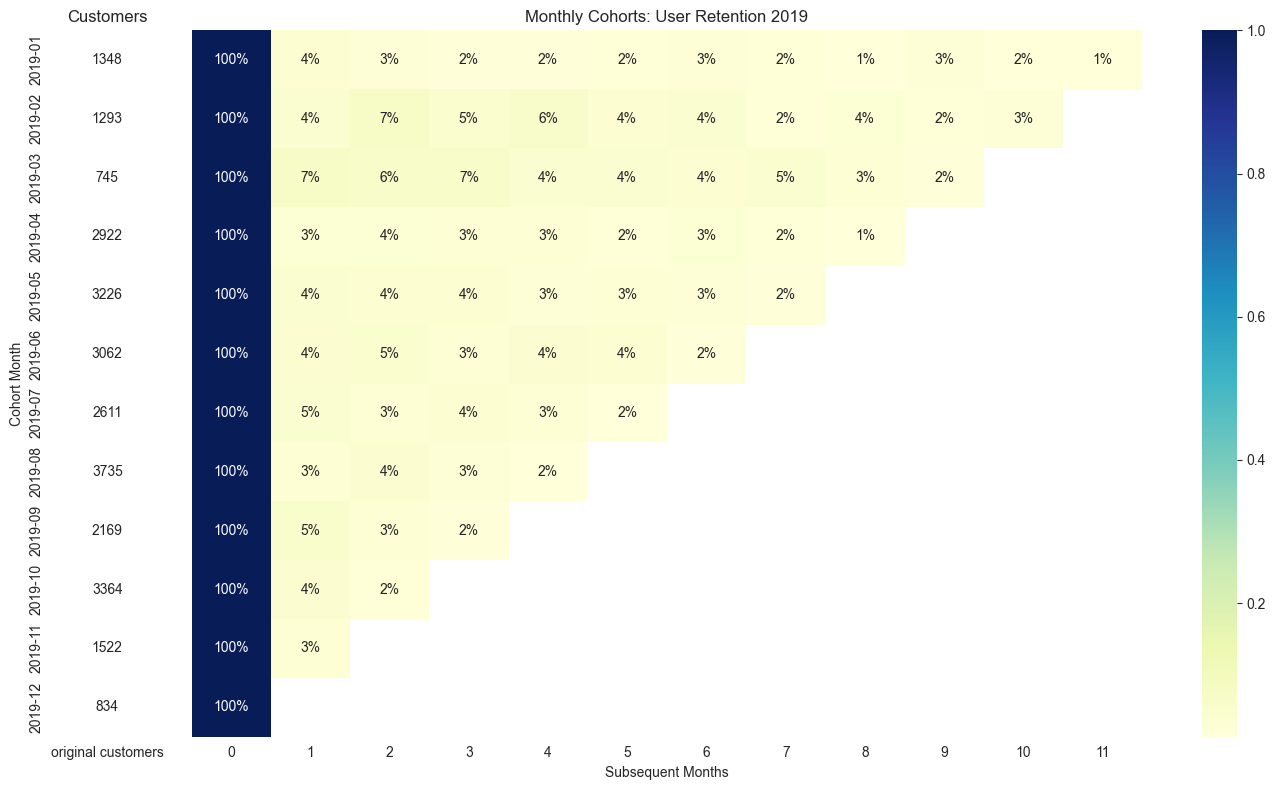

In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

# 1. cohort size = cột month_0
cohort_size = df_cohort_pivot.iloc[:, 0]

# 2. retention matrix %
retention_matrix = df_cohort_pivot.divide(cohort_size, axis=0)

# 3. tạo dataframe cohort size để vẽ bên trái
cohort_size_df = pd.DataFrame(cohort_size)
cohort_size_df.columns = ["original customers"]

# 4. vẽ
with sns.axes_style("white"):
    fig, ax = plt.subplots(
        1, 2,
        figsize=(14, 8),
        sharey=True,
        gridspec_kw={"width_ratios": [1, 11]}
    )

    # Bảng original customers bên trái
    white_cmap = mcolors.ListedColormap(["white"])

    sns.heatmap(
        cohort_size_df,
        annot=True,
        cbar=False,
        fmt="g",
        cmap=white_cmap,
        ax=ax[0]
    )

    ax[0].set_title("Customers")
    ax[0].set_xlabel("")
    ax[0].set_ylabel("Cohort Month")

    # Heatmap retention bên phải
    sns.heatmap(
        retention_matrix,
        mask=retention_matrix.isnull(),
        annot=True,
        fmt=".0%",
        cmap="YlGnBu",
        ax=ax[1]
    )

    ax[1].set_title("Monthly Cohorts: User Retention 2019")
    ax[1].set_xlabel("Subsequent Months")
    ax[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

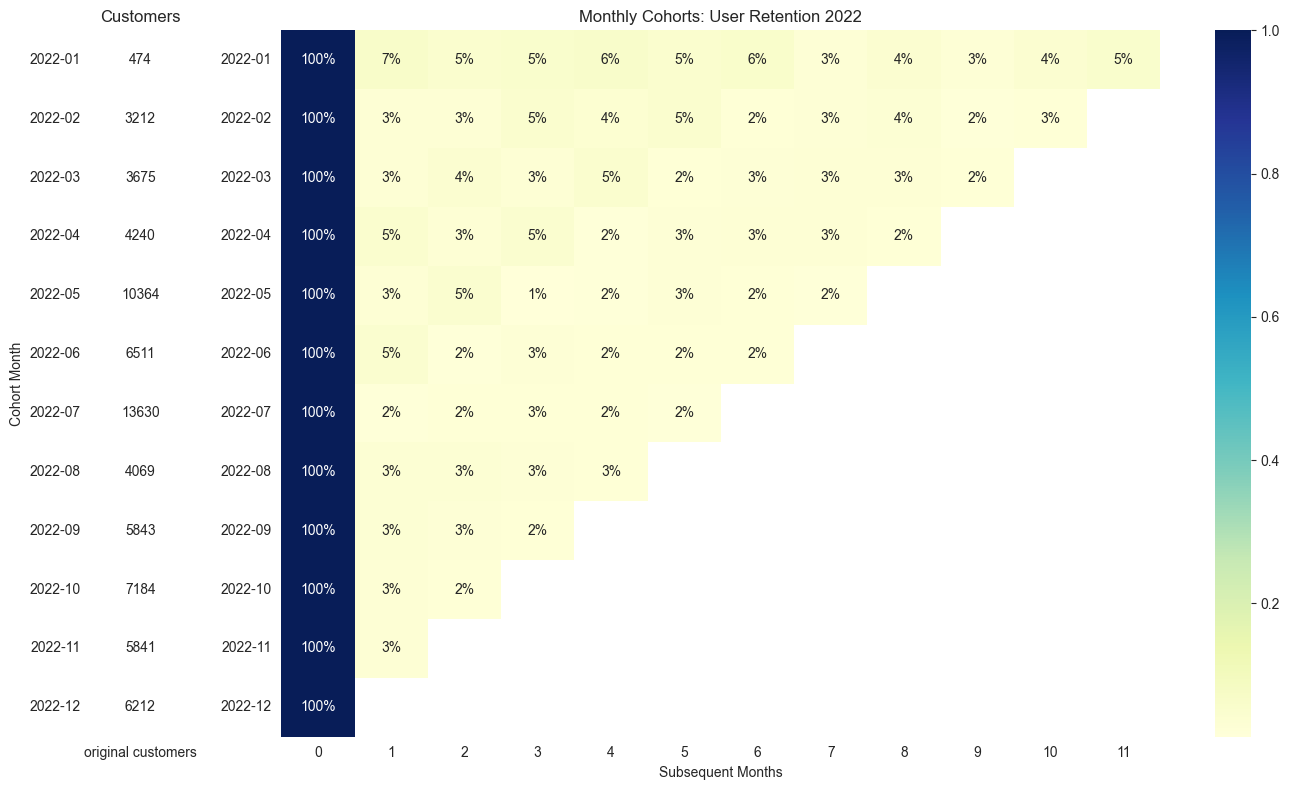

In [28]:
# ===== STEP 1: FILTER DATA 2022 + SUCCESSFUL ORDERS =====

df_selected_time = df_fact_ticket[
    (pd.to_datetime(df_fact_ticket["time"]) >= "2022-01-01") &
    (pd.to_datetime(df_fact_ticket["time"]) < "2023-01-01") &
    (df_fact_ticket["status_id"] == 1)
].copy()

df_selected_time["time"] = pd.to_datetime(df_selected_time["time"])

# ===== STEP 2: CREATE COHORT COLUMNS =====

df_selected_time["first_month"] = (
    df_selected_time
    .groupby("customer_id")["time"]
    .transform("min")
    .dt.to_period("M")
)

df_selected_time["current_month"] = (
    df_selected_time["time"]
    .dt.to_period("M")
)

df_selected_time["subsequent_month"] = (
    df_selected_time["current_month"] - df_selected_time["first_month"]
).apply(attrgetter("n"))

# ===== STEP 3: GROUP BY COHORT =====

df_cohort = (
    df_selected_time
    .groupby(["first_month", "current_month", "subsequent_month"])
    .agg(n_customers=("customer_id", "nunique"))
    .reset_index()
)

# ===== STEP 4: PIVOT TABLE =====

df_cohort_pivot = (
    df_cohort
    .pivot_table(
        index="first_month",
        columns="subsequent_month",
        values="n_customers"
    )
)

# ===== STEP 5: RETENTION MATRIX =====

cohort_size = df_cohort_pivot.iloc[:, 0]

retention_matrix = (
    df_cohort_pivot
    .divide(cohort_size, axis=0)
)

# ===== STEP 6: COHORT SIZE TABLE =====

cohort_size_df = pd.DataFrame(cohort_size)
cohort_size_df.columns = ["original customers"]

# ===== STEP 7: PLOT COHORT HEATMAP =====

with sns.axes_style("white"):

    fig, ax = plt.subplots(
        1, 2,
        figsize=(14, 8),
        gridspec_kw={"width_ratios": [1, 11]}
    )

    white_cmap = mcolors.ListedColormap(["white"])

    # LEFT: original customers
    sns.heatmap(
        cohort_size_df,
        annot=True,
        cbar=False,
        fmt="g",
        cmap=white_cmap,
        ax=ax[0]
    )

    ax[0].set_title("Customers")
    ax[0].set_xlabel("")
    ax[0].set_ylabel("Cohort Month")
    ax[0].set_yticklabels(cohort_size_df.index.astype(str), rotation=0)

    # RIGHT: retention heatmap
    sns.heatmap(
        retention_matrix,
        mask=retention_matrix.isnull(),
        annot=True,
        fmt=".0%",
        cmap="YlGnBu",
        ax=ax[1]
    )

    ax[1].set_title("Monthly Cohorts: User Retention 2022")
    ax[1].set_xlabel("Subsequent Months")
    ax[1].set_ylabel("")
    ax[1].set_yticklabels(retention_matrix.index.astype(str), rotation=0)

    plt.tight_layout()
    plt.show()

🎯 6. Final Conclusion
🔥 Key Finding

The platform demonstrates strong acquisition capability but weak retention capability across both years.

While 2022 achieved significantly larger customer volumes, retention rates remained consistently low and comparable to 2019.

This suggests that customer growth was primarily driven by external demand factors such as promotions and movie releases rather than sustainable customer loyalty.

🎯 Business Recommendations
🚀 Improve post-purchase engagement
personalized recommendations
loyalty programs
membership tiers
🚀 Convert transactional users into recurring users
targeted remarketing
retention campaigns after booking
cross-selling upcoming movies
🚀 Reduce dependence on blockbuster releases
improve platform stickiness
encourage habitual app usage
develop ecosystem-based engagement

## Compare: Retention of Promotion Customers & Organic Customers


In [3]:
df_fact_ticket.head(5)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,no_error,"iPhone13,1",mobile
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,no_error,browser,website
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,Male,1989-05-18,no_campaign,Order successful,no_error,unknown,mobile
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,Male,1997-08-31,direct discount,Order successful,no_error,devicemodel,mobile
4,776efd7bda0b715084430e6385f67746,100965,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,Male,1988-09-20,direct discount,Order successful,no_error,devicemodel,mobile


In [5]:
# 1. Lọc dữ liệu theo status và thời gian, chỉ giữ các cột cần thiết, rồi sắp xếp
df_data_check = (
    df_fact_ticket[(df_fact_ticket['status_id']==1) & (df_fact_ticket['time'] > '2022-01-01')]
    [['customer_id', 'ticket_id', 'time', 'campaign_type']]
    .sort_values(by=['customer_id', 'time'])
)

# 2. Đánh số thứ tự giao dịch cho từng customer_id
df_data_check['row_number'] = df_data_check.groupby('customer_id').cumcount() + 1

# 3. Kiểm tra kết quả
df_data_check.head(10)

,customer_id,ticket_id,time,campaign_type,row_number
66483,100003,34c4764b4afa000af4c33a525f20eace,2022-05-22 12:52:12.105,no_campaign,1
10000,100004,1c4aa39842bfc83dbb5856c25a33d9cb,2022-12-20 06:26:21.373,no_campaign,1
108792,100007,5565ba5e22475c7cce298a2bea470428,2022-03-21 17:57:18.460,direct discount,1
0,100009,4f5200dcdcf2396b8d50ff84bf423f32,2022-07-08 17:46:36.145,direct discount,1
5585,100009,0724203b5146b0ebae6e3678ed7eccde,2022-12-24 09:32:45.477,direct discount,2
69403,100013,f95441286dcfa045f61a5760662616e1,2022-05-05 12:22:44.587,no_campaign,1
140481,100018,1e40fb2d0f6264ed3127f79b1a12c9c9,2022-09-07 21:13:17.896,no_campaign,1
90593,100018,9a959ff1649950949ff2c0aff4b62205,2022-11-19 16:25:43.981,direct discount,2
35269,100020,af02fc96a6703af7d93162d9f8c61dba,2022-05-28 19:09:37.936,direct discount,1
16648,100023,5ed44ff62214268ffcb14d4ea78b04d8,2022-05-16 08:45:42.397,direct discount,1


In [6]:
df_data_check["type"] = df_data_check["campaign_type"].apply(
    lambda x: "non-promotion" if x == "no_campaign" else "promotion"
)

In [7]:
df_data_check.head(10)

,customer_id,ticket_id,time,campaign_type,row_number,type
66483,100003,34c4764b4afa000af4c33a525f20eace,2022-05-22 12:52:12.105,no_campaign,1,non-promotion
10000,100004,1c4aa39842bfc83dbb5856c25a33d9cb,2022-12-20 06:26:21.373,no_campaign,1,non-promotion
108792,100007,5565ba5e22475c7cce298a2bea470428,2022-03-21 17:57:18.460,direct discount,1,promotion
0,100009,4f5200dcdcf2396b8d50ff84bf423f32,2022-07-08 17:46:36.145,direct discount,1,promotion
5585,100009,0724203b5146b0ebae6e3678ed7eccde,2022-12-24 09:32:45.477,direct discount,2,promotion
69403,100013,f95441286dcfa045f61a5760662616e1,2022-05-05 12:22:44.587,no_campaign,1,non-promotion
140481,100018,1e40fb2d0f6264ed3127f79b1a12c9c9,2022-09-07 21:13:17.896,no_campaign,1,non-promotion
90593,100018,9a959ff1649950949ff2c0aff4b62205,2022-11-19 16:25:43.981,direct discount,2,promotion
35269,100020,af02fc96a6703af7d93162d9f8c61dba,2022-05-28 19:09:37.936,direct discount,1,promotion
16648,100023,5ed44ff62214268ffcb14d4ea78b04d8,2022-05-16 08:45:42.397,direct discount,1,promotion


In [8]:
df_data_check[(df_data_check["type"] == "promotion" ) & (df_data_check["row_number"] == 1)]['customer_id'].nunique()

46188

In [9]:
total_promotion_customers = df_data_check[df_data_check["type"] == "promotion"]['customer_id'].nunique()
print(total_promotion_customers)

47506


In [10]:
46188/47506

0.9722561360670231

In [12]:
# ===== Nhóm promotion =====
# Khách hàng có đơn đầu tiên là promotion
first_promo_customers = df_data_check[
    (df_data_check['type'] == 'promotion') & 
    (df_data_check['row_number'] == 1)
]['customer_id'].unique()

# Lọc giao dịch lần 2 của nhóm promotion
second_purchase_promo = df_data_check[
    (df_data_check['customer_id'].isin(first_promo_customers)) &
    (df_data_check['row_number'] == 2)
]

# Tỷ lệ retention lần 2 nhóm promotion
promo_returned = second_purchase_promo['customer_id'].nunique()
promo_retention_rate = promo_returned / len(first_promo_customers) * 100


# ===== Nhóm non-promotion (organic) =====
# Khách hàng có đơn đầu tiên là non-promotion
first_nonpromo_customers = df_data_check[
    (df_data_check['type'] == 'non-promotion') & 
    (df_data_check['row_number'] == 1)
]['customer_id'].unique()

# Lọc giao dịch lần 2 của nhóm non-promotion
second_purchase_nonpromo = df_data_check[
    (df_data_check['customer_id'].isin(first_nonpromo_customers)) &
    (df_data_check['row_number'] == 2)
]

# Tỷ lệ retention lần 2 nhóm non-promotion
nonpromo_returned = second_purchase_nonpromo['customer_id'].nunique()
nonpromo_retention_rate = nonpromo_returned / len(first_nonpromo_customers) * 100


# ===== In kết quả so sánh =====
print(f"Promotion: {len(first_promo_customers)} khách lần đầu, {promo_returned} quay lại, tỷ lệ {promo_retention_rate:.2f}%")
print(f"Non-promotion: {len(first_nonpromo_customers)} khách lần đầu, {nonpromo_returned} quay lại, tỷ lệ {nonpromo_retention_rate:.2f}%")

Promotion: 46188 khách lần đầu, 6045 quay lại, tỷ lệ 13.09%
Non-promotion: 25067 khách lần đầu, 3057 quay lại, tỷ lệ 12.20%


## Payment Success Rate


In [4]:
df_success_rate = df_fact_ticket.copy()

df_success_rate["year_month"] = df_success_rate["time"].dt.to_period("M")

def calculate_n_success(x):
    return (x == 1).sum()

df_sr = (
    df_success_rate
    .groupby("year_month")
    .agg(
        n_orders=("ticket_id", "count"),
        n_success=("status_id", calculate_n_success)
    )
    .assign(
        success_rate=lambda x: (x["n_success"] / x["n_orders"]) * 100
    )
    .reset_index()
)

df_sr.head(5)

,year_month,n_orders,n_success,success_rate
0,2019-01,2019,1359,67.310550
1,2019-02,1626,1427,87.761378
2,2019-03,1004,866,86.254980
3,2019-04,4069,3190,78.397641
4,2019-05,4430,3617,81.647856


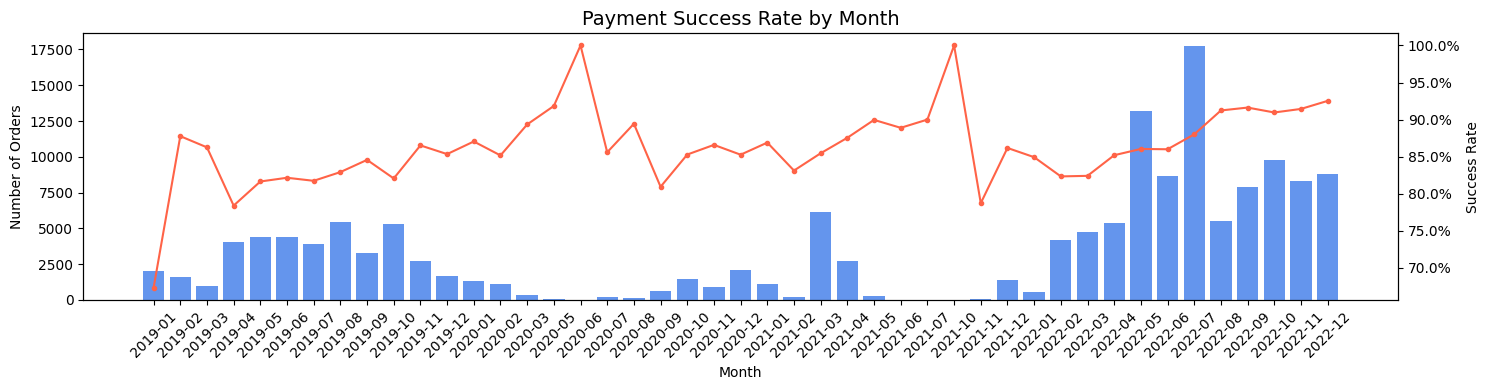

In [5]:
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plt

# Convert year_month to string for better display
df_sr["year_month"] = df_sr["year_month"].astype(str)

fig, ax1 = plt.subplots(figsize=(15, 4))

# Bar chart: total orders
ax1.bar(
    df_sr["year_month"],
    df_sr["n_orders"],
    color="cornflowerblue",
    label="Total Orders"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Orders")
ax1.tick_params(axis="x", rotation=45)

# Line chart: success rate
ax2 = ax1.twinx()

ax2.plot(
    df_sr["year_month"],
    df_sr["success_rate"],
    color="tomato",
    marker="o",
    markersize=3,
    label="Success Rate"
)

ax2.set_ylabel("Success Rate")
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=100))

plt.title("Payment Success Rate by Month", fontsize=14)

plt.tight_layout()
plt.show()

### Errors

In [11]:
# ===== FAILURE REASON ANALYSIS - ALL TIME =====

df_failed_orders = df_fact_ticket[
    df_fact_ticket["status_id"] != 1
].copy()

df_failed_orders["year_month"] = df_failed_orders["time"].dt.to_period("M")

df_failed_orders.head()

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,year_month
6,4dd5ea254588f1f287c6c2753286c719,101001,bank account,125.0,74885e0163f3c8f3d78a8fb31f9aabef,5.16,2.31,2.85,2022-07-08 13:23:28.482,-5,83330,Thor: Love And Thunder,Male,1996-05-11,direct discount,Payment failed from bank,external,browser,website,2022-07
31,921bfd15df8f47bd3fd5bb8cbf12e1be,105101,credit card,190.0,b3a0ff7c362bf12547293abc107891cc,10.31,2.31,8.00,2022-07-09 09:34:33.614,-5,83330,Thor: Love And Thunder,Male,1994-03-13,direct discount,Payment failed from bank,external,devicemodel,mobile,2022-07
43,1e657e24768c5447f9a302de87817d7c,108210,credit card,11.0,40215b653d2f040f320a6603430e70ba,10.71,2.51,8.20,2022-07-08 17:28:06.725,-5,83330,Thor: Love And Thunder,Male,1983-12-22,direct discount,Payment failed from bank,external,devicemodel,mobile,2022-07
45,ccda94158ea452e41eede29a3389db45,110287,money in app,13.0,37c800f03d2dbf0ba996d54b691dec61,5.16,2.31,2.85,2022-07-06 10:14:45.490,-6,83330,Thor: Love And Thunder,Male,1996-06-10,direct discount,Need verify your account to continue,customer,devicemodel,mobile,2022-07
46,1668ab8db8400dec2ef0759c66d29328,110287,money in app,13.0,37c800f03d2dbf0ba996d54b691dec61,5.16,2.31,2.85,2022-07-06 10:22:38.396,-6,83330,Thor: Love And Thunder,Male,1996-06-10,direct discount,Need verify your account to continue,customer,devicemodel,mobile,2022-07


In [12]:
error_summary = (
    df_failed_orders
    .groupby("error_group")
    .agg(
        failed_orders=("ticket_id", "count")
    )
    .sort_values("failed_orders", ascending=False)
    .reset_index()
)

error_summary["failure_percentage"] = (
    error_summary["failed_orders"] /
    error_summary["failed_orders"].sum() * 100
).round(2)

error_summary

,error_group,failed_orders,failure_percentage
0,external,15683,74.52
1,customer,5112,24.29
2,internal,251,1.19


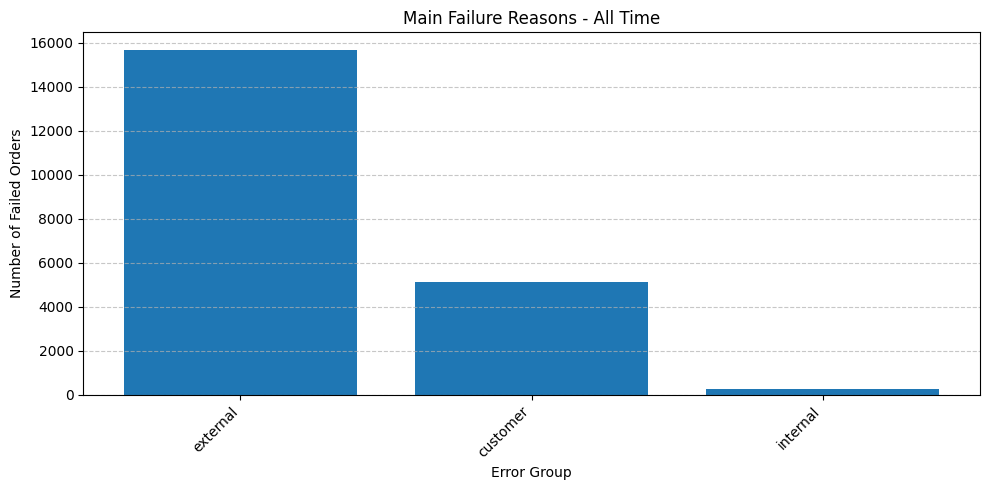

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    error_summary["error_group"],
    error_summary["failed_orders"]
)

plt.title("Main Failure Reasons - All Time")
plt.xlabel("Error Group")
plt.ylabel("Number of Failed Orders")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

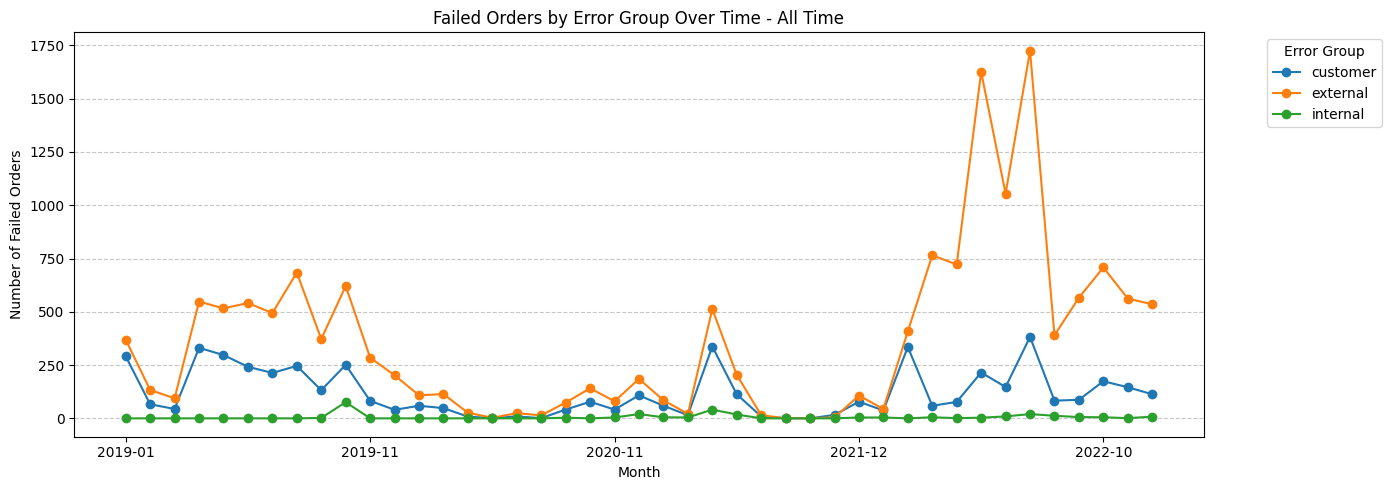

In [14]:
df_error_monthly = (
    df_failed_orders
    .groupby(["year_month", "error_group"])
    .agg(
        failed_orders=("ticket_id", "count")
    )
    .reset_index()
)

error_monthly_pivot = (
    df_error_monthly
    .pivot_table(
        index="year_month",
        columns="error_group",
        values="failed_orders",
        fill_value=0
    )
)

error_monthly_pivot.index = error_monthly_pivot.index.astype(str)

error_monthly_pivot.plot(
    kind="line",
    marker="o",
    figsize=(14, 5)
)

plt.title("Failed Orders by Error Group Over Time - All Time")
plt.xlabel("Month")
plt.ylabel("Number of Failed Orders")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Error Group", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [15]:
# ===== FAILURE DISTRIBUTION BY MONTH AND ERROR DESCRIPTION =====

df_error = df_fact_ticket[df_fact_ticket["status_id"] != 1].copy()

df_error["year_month"] = df_error["time"].dt.to_period("M").astype(str)

df_error = (
    df_error
    .groupby(["year_month", "description"])
    .agg(
        n_orders=("ticket_id", "count")
    )
    .sort_values(["year_month", "n_orders"], ascending=[True, False])
    .reset_index()
)

df_error.head(10)

,year_month,description,n_orders
0,2019-01,No response from your bank,228
1,2019-01,Insufficient funds in customer account. Please...,217
2,2019-01,Payment failed from bank,141
3,2019-01,Password locked due to multiple incorrect atte...,56
4,2019-01,Payment overdue,18
5,2019-02,No response from your bank,67
6,2019-02,Payment failed from bank,66
7,2019-02,Insufficient funds in customer account. Please...,42
8,2019-02,Payment overdue,13
9,2019-02,Password locked due to multiple incorrect atte...,11


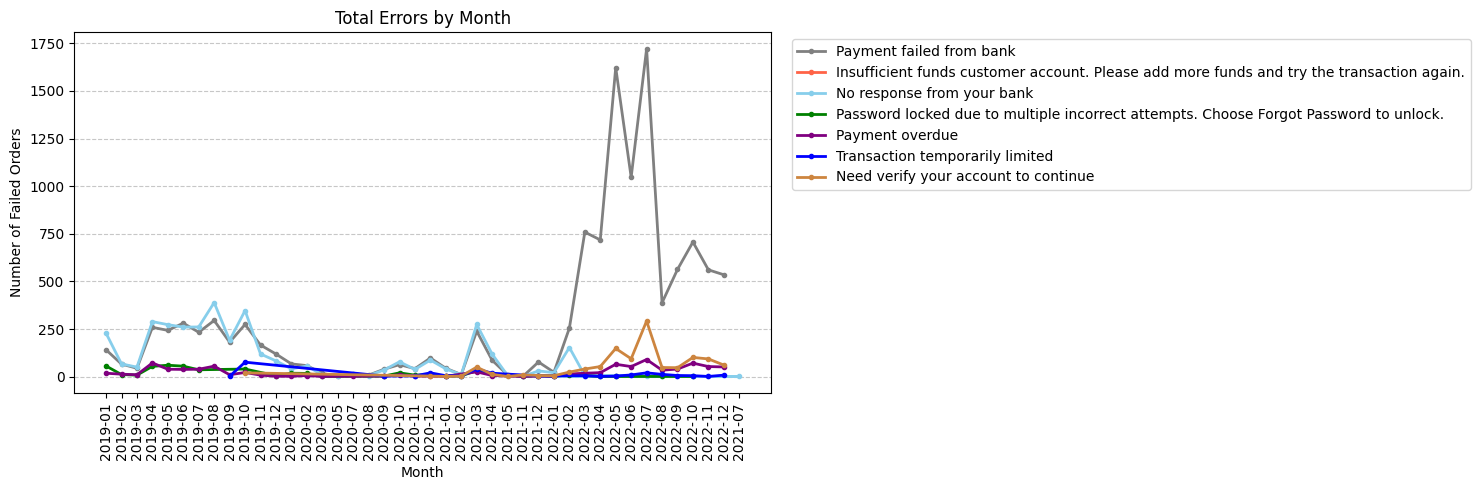

In [17]:
import matplotlib.pyplot as plt

error_color_pairs = [
    ("Payment failed from bank", "gray"),
    ("Insufficient funds customer account. Please add more funds and try the transaction again.", "tomato"),
    ("No response from your bank", "skyblue"),
    ("Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.", "green"),
    ("Payment overdue", "purple"),
    ("Transaction temporarily limited", "blue"),
    ("Need verify your account to continue", "peru")
]

plt.figure(figsize=(15, 5))

for error, color in error_color_pairs:
    df_error_line = df_error[df_error["description"] == error]

    plt.plot(
        df_error_line["year_month"],
        df_error_line["n_orders"],
        label=error,
        marker="o",
        color=color,
        linewidth=2,
        markersize=3
    )

plt.title("Total Errors by Month")
plt.xlabel("Month")
plt.ylabel("Number of Failed Orders")
plt.xticks(rotation=90)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [20]:
# ===== CREATE CUSTOMER VALUE TABLE =====

df_customer_base = df_fact_ticket.copy()

# Convert time to datetime if needed
df_customer_base["time"] = pd.to_datetime(df_customer_base["time"], errors="coerce")

# Create promotion / non-promotion type
df_customer_base["type"] = df_customer_base["campaign_type"].apply(
    lambda x: "non-promotion" if x == "no_campaign" else "promotion"
)

# Create date and month columns
df_customer_base["date"] = df_customer_base["time"].dt.date
df_customer_base["year_month"] = df_customer_base["time"].dt.to_period("M")

# Function to count promotion orders
def calculate_n_promotion(x):
    return (x == "promotion").sum()

# Create customer-level metrics
df_customer_value = (
    df_customer_base
    .groupby("customer_id")
    .agg(
        n_total=("ticket_id", "count"),
        n_failed=("status_id", lambda x: (x != 1).sum()),
        n_success=("status_id", lambda x: (x == 1).sum()),
        s_money=("original_price", "sum"),
        s_discount=("discount_value", "sum"),
        n_days=("date", "nunique"),
        n_months=("year_month", "nunique"),
        n_promotions=("type", calculate_n_promotion)
    )
    .reset_index()
)

# Calculate rates
df_customer_value["success_rate"] = (
    df_customer_value["n_success"] / df_customer_value["n_total"]
)

df_customer_value["promotion_rate"] = (
    df_customer_value["n_promotions"] / df_customer_value["n_total"]
)

df_customer_value["discount_rate"] = (
    df_customer_value["s_discount"] / df_customer_value["s_money"]
)

df_customer_value.head()

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_days,n_months,n_promotions,success_rate,promotion_rate,discount_rate
0,100001,1,0,1,7.42,2.06,1,1,1,1.0,1.000000,0.277628
1,100003,6,0,6,60.95,2.56,6,6,1,1.0,0.166667,0.042002
2,100004,1,0,1,32.25,0.00,1,1,0,1.0,0.000000,0.000000
3,100005,1,0,1,9.49,2.06,1,1,1,1.0,1.000000,0.217071
4,100006,1,0,1,12.37,0.00,1,1,0,1.0,0.000000,0.000000


In [21]:
list_sr_0 = list(
    df_customer_value[
        df_customer_value["success_rate"] < 0.1
    ]["customer_id"].unique()
)

len(list_sr_0)

13701

In [24]:
df_sr_0_metric = (
    df_customer_base[
        df_customer_base["customer_id"].isin(list_sr_0)
    ]
    .groupby("customer_id")
    .agg(
        n_orders=("ticket_id", "count"),
        s_money=("original_price", "sum"),
        s_discount=("discount_value", "sum"),
        n_promotions=("type", calculate_n_promotion)
    )
    .reset_index()
)

df_sr_0_metric["promotion_rate"] = (
    df_sr_0_metric["n_promotions"] / df_sr_0_metric["n_orders"]
)

df_sr_0_metric["discount_rate"] = (
    df_sr_0_metric["s_discount"] / df_sr_0_metric["s_money"]
)

df_sr_0_metric.head()

,customer_id,n_orders,s_money,s_discount,n_promotions,promotion_rate,discount_rate
0,100012,1,69.12,5.07,1,1.0,0.073351
1,100025,1,15.01,1.32,1,1.0,0.087941
2,100041,2,22.32,3.36,2,1.0,0.150538
3,100044,1,8.66,0.00,0,0.0,0.000000
4,100069,1,14.85,0.00,0,0.0,0.000000


In [25]:
df_sr_0_failed = df_fact_ticket[
    (df_fact_ticket["customer_id"].isin(list_sr_0)) &
    (df_fact_ticket["status_id"] != 1)
].copy()

sr_0_error_summary = (
    df_sr_0_failed
    .groupby("description")
    .agg(
        failed_orders=("ticket_id", "count"),
        customers=("customer_id", "nunique")
    )
    .sort_values("failed_orders", ascending=False)
    .reset_index()
)

sr_0_error_summary.head(10)

,description,failed_orders,customers
0,Payment failed from bank,8273,7867
1,No response from your bank,2545,2365
2,Insufficient funds in customer account. Please...,1877,1824
3,Need verify your account to continue,916,838
4,Payment overdue,596,593
5,Password locked due to multiple incorrect atte...,377,344
6,Transaction temporarily limited,202,178


In [27]:
# Failed orders from low success rate customers
df_low_sr_failed = df_fact_ticket[
    (df_fact_ticket["customer_id"].isin(list_sr_0)) &
    (df_fact_ticket["status_id"] != 1)
].copy()

df_low_sr_failed["year_month"] = df_low_sr_failed["time"].dt.to_period("M")

df_low_sr_failed.head()

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,year_month
45,ccda94158ea452e41eede29a3389db45,110287,money in app,13.0,37c800f03d2dbf0ba996d54b691dec61,5.16,2.31,2.85,2022-07-06 10:14:45.490,-6,83330,Thor: Love And Thunder,Male,1996-06-10,direct discount,Need verify your account to continue,customer,devicemodel,mobile,2022-07
46,1668ab8db8400dec2ef0759c66d29328,110287,money in app,13.0,37c800f03d2dbf0ba996d54b691dec61,5.16,2.31,2.85,2022-07-06 10:22:38.396,-6,83330,Thor: Love And Thunder,Male,1996-06-10,direct discount,Need verify your account to continue,customer,devicemodel,mobile,2022-07
52,9dfe97ddca7e3947620c64976045bbfd,112658,debit card,125.0,b13079188e90c66683bb299a87e95dcd,15.47,2.31,13.16,2022-07-08 15:09:17.384,-5,83330,Thor: Love And Thunder,Female,1995-03-16,direct discount,Payment failed from bank,external,browser,website,2022-07
66,5e5fd2c7bbce78db91bbdd8975253267,115400,bank account,79.0,a67bcdbc7027b4d254a21e4da9a0cbe8,6.80,0.00,6.80,2022-07-18 11:57:18.420,-5,0,Thor: Love And Thunder,Female,1996-01-27,no_campaign,Payment failed from bank,external,devicemodel,mobile,2022-07
73,f139559ed3f2d554729d20d1c945de61,116820,bank account,33.0,638b4ad2d80884acec322ca2c5cbdf6b,5.16,2.31,2.85,2022-07-08 01:47:39.850,-5,83330,Thor: Love And Thunder,Male,1989-10-21,direct discount,Payment failed from bank,external,devicemodel,mobile,2022-07


In [28]:
# Error distribution by month and error description
df_error_0 = (
    df_low_sr_failed
    .groupby(["year_month", "description"])
    .agg(
        n_orders=("ticket_id", "count")
    )
    .sort_values(["year_month", "n_orders"], ascending=[True, False])
    .reset_index()
)

df_error_0.head(20)

,year_month,description,n_orders
0,2019-01,No response from your bank,206
1,2019-01,Insufficient funds in customer account. Please...,196
2,2019-01,Payment failed from bank,114
3,2019-01,Password locked due to multiple incorrect atte...,49
4,2019-01,Payment overdue,16
5,2019-02,No response from your bank,49
6,2019-02,Payment failed from bank,46
7,2019-02,Insufficient funds in customer account. Please...,31
8,2019-02,Password locked due to multiple incorrect atte...,7
9,2019-02,Payment overdue,7


In [29]:
df_error_0["monthly_failed_total"] = (
    df_error_0
    .groupby("year_month")["n_orders"]
    .transform("sum")
)

df_error_0["error_pct_in_month"] = (
    df_error_0["n_orders"] /
    df_error_0["monthly_failed_total"] * 100
).round(2)

df_error_0.head(20)

,year_month,description,n_orders,monthly_failed_total,error_pct_in_month
0,2019-01,No response from your bank,206,581,35.46
1,2019-01,Insufficient funds in customer account. Please...,196,581,33.73
2,2019-01,Payment failed from bank,114,581,19.62
3,2019-01,Password locked due to multiple incorrect atte...,49,581,8.43
4,2019-01,Payment overdue,16,581,2.75
5,2019-02,No response from your bank,49,140,35.00
6,2019-02,Payment failed from bank,46,140,32.86
7,2019-02,Insufficient funds in customer account. Please...,31,140,22.14
8,2019-02,Password locked due to multiple incorrect atte...,7,140,5.00
9,2019-02,Payment overdue,7,140,5.00


In [30]:
low_sr_error_summary = (
    df_low_sr_failed
    .groupby("description")
    .agg(
        failed_orders=("ticket_id", "count"),
        customers=("customer_id", "nunique")
    )
    .sort_values("failed_orders", ascending=False)
    .reset_index()
)

low_sr_error_summary["failed_order_pct"] = (
    low_sr_error_summary["failed_orders"] /
    low_sr_error_summary["failed_orders"].sum() * 100
).round(2)

low_sr_error_summary.head(10)

,description,failed_orders,customers,failed_order_pct
0,Payment failed from bank,8273,7867,55.95
1,No response from your bank,2545,2365,17.21
2,Insufficient funds in customer account. Please...,1877,1824,12.69
3,Need verify your account to continue,916,838,6.20
4,Payment overdue,596,593,4.03
5,Password locked due to multiple incorrect atte...,377,344,2.55
6,Transaction temporarily limited,202,178,1.37


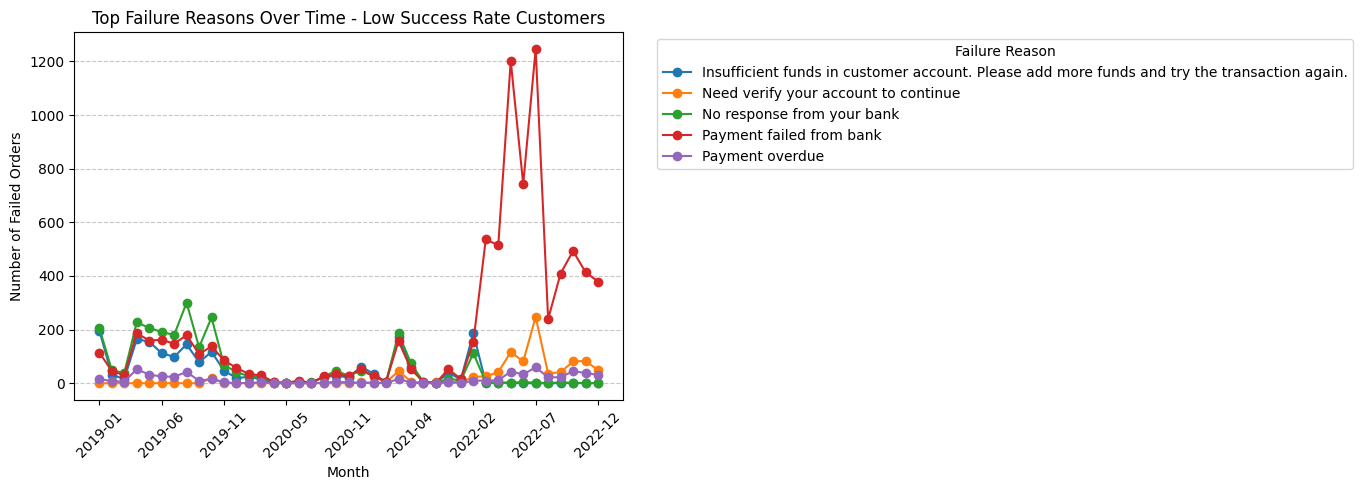

In [31]:
top_5_errors = low_sr_error_summary.head(5)["description"]

df_error_0_top5 = df_error_0[
    df_error_0["description"].isin(top_5_errors)
].copy()

error_0_pivot = (
    df_error_0_top5
    .pivot_table(
        index="year_month",
        columns="description",
        values="n_orders",
        fill_value=0
    )
)

error_0_pivot.index = error_0_pivot.index.astype(str)

error_0_pivot.plot(
    kind="line",
    marker="o",
    figsize=(14, 5)
)

plt.title("Top Failure Reasons Over Time - Low Success Rate Customers")
plt.xlabel("Month")
plt.ylabel("Number of Failed Orders")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Failure Reason", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [33]:
low_sr_order_attempts = (
    df_fact_ticket[
        df_fact_ticket["customer_id"].isin(list_sr_0)
    ]
    .groupby("customer_id")
    .agg(
        n_orders=("ticket_id", "count"),
        n_failed=("status_id", lambda x: (x != 1).sum()),
        n_success=("status_id", lambda x: (x == 1).sum())
    )
    .reset_index()
)

low_sr_order_attempts["n_orders"].value_counts().sort_index()

n_orders
1    12730
2      868
3       94
4        7
5        2
Name: count, dtype: int64

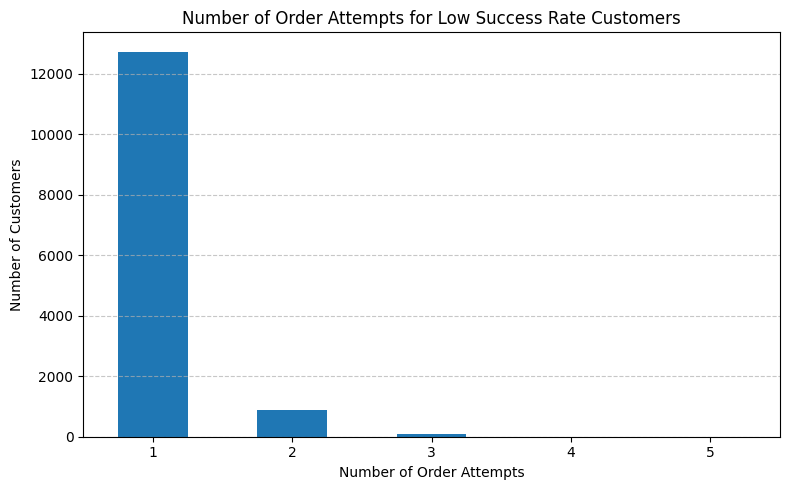

In [34]:
plt.figure(figsize=(8, 5))

low_sr_order_attempts["n_orders"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Order Attempts for Low Success Rate Customers")
plt.xlabel("Number of Order Attempts")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

- This section focuses on customers with very low success rates.

- Failed orders are filtered using `status_id != 1`.

- Error descriptions are grouped by month to identify which issues caused the most failed transactions over time.

- The overall error summary shows the main failure reasons for low success rate customers.

- If most customers only made one order attempt, this suggests that many users failed once and did not retry.

- This may indicate checkout friction, payment gateway issues, insufficient funds, or weak recovery flow after payment failure.

- Understanding these failure reasons can help improve payment success rate, reduce customer drop-off, and increase completed transactions.
